# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:Bhavya Garg** __ **Roll No.:1RUA25CSE0115** __ **Section:G**

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [3]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [7]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [8]:
# TODO: Q1 — shape, dtypes, describe(), and missing-value check

print(df.shape)
print(df.dtypes)
print(df.describe())


(150, 6)
member_id                         str
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout                 str
dtype: object
       workout_duration_minutes  monthly_membership_fee_inr  \
count                   150.000                     150.000   
mean                     54.618                    2283.067   
std                      11.397                     984.837   
min                      27.800                     800.000   
25%                      48.050                    1515.000   
50%                      54.350                    2030.000   
75%                      62.875                    2825.000   
max                      81.000                    6420.000   

       attendance_percentage  weekly_visit_count  
count                150.000             150.000  
mean                  84.210               3.337  
std                    5.874

In [9]:
print(df.isnull().sum())

member_id                     0
workout_duration_minutes      0
monthly_membership_fee_inr    0
attendance_percentage         0
weekly_visit_count            0
preferred_workout             0
dtype: int64


## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [10]:
# TODO: Q2 — mean, median, mode for each numeric feature; mode of preferred_workout

#Workout Duration:-

print(df['workout_duration_minutes'].mean())
print(df['workout_duration_minutes'].median())
print(df['workout_duration_minutes'].mode())

54.618
54.349999999999994
0    57.8
Name: workout_duration_minutes, dtype: float64


In [11]:
#Monthly Fee:-
print(df['monthly_membership_fee_inr'].mean())
print(df['monthly_membership_fee_inr'].median())
print(df['monthly_membership_fee_inr'].mode())
#Monthly fee might be a littly positively skewed as mean is greater than median.

2283.0666666666666
2030.0
0    1440.0
Name: monthly_membership_fee_inr, dtype: float64


In [12]:
#attendance:-
print(df['attendance_percentage'].mean())
print(df['attendance_percentage'].median())
print(df['attendance_percentage'].mode())

84.21
85.1
0    85.1
1    88.5
Name: attendance_percentage, dtype: float64


In [13]:
#weekly_visit_count:-
print(df['weekly_visit_count'].mean())
print(df['weekly_visit_count'].median())
print(df['weekly_visit_count'].mode())

#weekly_visit_count might be a littly positively skewed as mean is greater than median.

3.3366666666666664
2.4
0    2.3
Name: weekly_visit_count, dtype: float64


In [14]:
#mode of the preferred workout:-
print(df['preferred_workout'].mode())

0     Cardio
1    Weights
Name: preferred_workout, dtype: str


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer:**

_(write here)_

In [15]:
#based on the observation from the mean , median and mode of all the numeric features, we can say that:-
#Monthy fees and weekly visit count are positively skewed as mean is greater than median.
#the most preferred workout is "cardio" and "weights" as they have the most occurance in the dataset.

### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [16]:
# TODO: Q4 — add the ₹80,000 outlier to a COPY of df, compare mean/median before vs. after

df_copy_1 = df.copy()

df_copy_1.loc[len(df_copy_1)] = ["M150", 54, 80000, 84, 3.3, "cardio"]

print("Before:- ")
print(df['monthly_membership_fee_inr'].mean())
print(df['monthly_membership_fee_inr'].median())

print("After:- ")
print(df_copy_1['monthly_membership_fee_inr'].mean())
print(df_copy_1['monthly_membership_fee_inr'].median())

Before:- 
2283.0666666666666
2030.0
After:- 
2797.748344370861
2030.0


**Your answer:**

_(write here)_

In [17]:
#the mean has increased after adding the outlier but the median has remained same in both instances
#this shows that the mean is sensitive to outliers and the median is robust to outliers.

## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [18]:
# TODO: Q5 — manual variance & standard deviation for workout_duration_minutes, then verify

x = df['workout_duration_minutes'].values
n = len(x)
mean_manual = sum(x) / n
variance_manual = sum((x - mean_manual) ** 2) / n
standard_deviation_manual = variance_manual ** 0.5

print("mean_manual:", mean_manual)
print("Manual Variance:", variance_manual)
print("Manual Standard Deviation:", standard_deviation_manual)

print("Automatic Mean:", df["workout_duration_minutes"].mean())
print("Automatic Variance:", df["workout_duration_minutes"].var())
print("Automatic Standard Deviation:", df["workout_duration_minutes"].std())

#values both manual and automatic calculation are almost same for variance and standard deviation.

mean_manual: 54.618
Manual Variance: 129.03187600000004
Manual Standard Deviation: 11.359219867578936
Automatic Mean: 54.618
Automatic Variance: 129.89786174496643
Automatic Standard Deviation: 11.397274312087362


### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Your answer (2–3 sentences):** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

_(write here)_

In [19]:
# TODO: Q6 — Q1, Q3, IQR, bounds, and outlier count for each of the four numeric features

#workout_duration_minutes
Q1_workout_duration = df['workout_duration_minutes'].quantile(0.25)
Q2_workout_duration = df['workout_duration_minutes'].quantile(0.5)
Q3_workout_duration = df['workout_duration_minutes'].quantile(0.75)
IQR_workout_duration = Q3_workout_duration - Q1_workout_duration    

print("IQR:-", IQR_workout_duration)

L_workout_duration = Q1_workout_duration - 1.5 * IQR_workout_duration
U_workout_duration = Q3_workout_duration + 1.5 * IQR_workout_duration

Outliers_workout_duration = df[(df['workout_duration_minutes'] < L_workout_duration) | (df['workout_duration_minutes'] > U_workout_duration)]
print("Number of Outliers:-", len(Outliers_workout_duration))

IQR:- 14.825000000000003
Number of Outliers:- 0


In [20]:
#monthly_membership_fee_inr
Q1_monthly_membership_fee_inr = df['monthly_membership_fee_inr'].quantile(0.25)
Q2_monthly_membership_fee_inr = df['monthly_membership_fee_inr'].quantile(0.5)
Q3_monthly_membership_fee_inr = df['monthly_membership_fee_inr'].quantile(0.75)
IQR_monthly_membership_fee_inr = Q3_monthly_membership_fee_inr - Q1_monthly_membership_fee_inr
print("IQR:-", IQR_monthly_membership_fee_inr)

L_monthly_membership_fee_inr = Q1_monthly_membership_fee_inr - 1.5 * IQR_monthly_membership_fee_inr
U_monthly_membership_fee_inr = Q3_monthly_membership_fee_inr + 1.5 * IQR_monthly_membership_fee_inr
Outliers_monthly_membership_fee_inr = df[(df['monthly_membership_fee_inr'] < L_monthly_membership_fee_inr) | (df['monthly_membership_fee_inr'] > U_monthly_membership_fee_inr)]
print("Number of Outliers:-", len(Outliers_monthly_membership_fee_inr))

IQR:- 1310.0
Number of Outliers:- 2


In [21]:
#attendance_percentage
Q1_attendance_percentage = df['attendance_percentage'].quantile(0.25)
Q2_attendance_percentage = df['attendance_percentage'].quantile(0.5)
Q3_attendance_percentage = df['attendance_percentage'].quantile(0.75)
IQR_attendance_percentage = Q3_attendance_percentage - Q1_attendance_percentage
print("IQR:-", IQR_attendance_percentage)

L_attendance_percentage = Q1_attendance_percentage - 1.5 * IQR_attendance_percentage
U_attendance_percentage = Q3_attendance_percentage + 1.5 * IQR_attendance_percentage
Outliers_attendance_percentage = df[(df['attendance_percentage'] < L_attendance_percentage) | (df['attendance_percentage'] > U_attendance_percentage)]
print("Number of Outliers:-", len(Outliers_attendance_percentage))

IQR:- 8.600000000000009
Number of Outliers:- 1


In [22]:
#weekly_visit_count
Q1_weekly_visit_count = df['weekly_visit_count'].quantile(0.25)
Q2_weekly_visit_count = df['weekly_visit_count'].quantile(0.5)
Q3_weekly_visit_count = df['weekly_visit_count'].quantile(0.75)
IQR_weekly_visit_count = Q3_weekly_visit_count - Q1_weekly_visit_count
print("IQR:-", IQR_weekly_visit_count)

L_weekly_visit_count = Q1_weekly_visit_count - 1.5 * IQR_weekly_visit_count
U_weekly_visit_count = Q3_weekly_visit_count + 1.5 * IQR_weekly_visit_count
Outliers_weekly_visit_count = df[(df['weekly_visit_count'] < L_weekly_visit_count) | (df['weekly_visit_count'] > U_weekly_visit_count)]
print("Number of Outliers:-", len(Outliers_weekly_visit_count))

IQR:- 3.5
Number of Outliers:- 0


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [23]:
# TODO: Q7 — skewness & excess kurtosis for each numeric feature, plus your classification

#workout_duration_minutes
print(df["workout_duration_minutes"].skew())
print(df["workout_duration_minutes"].kurtosis())
#as you can see the workout_duration_minutes is positively (right) skewed and pykurtic kurtosis

0.08068201795955016
-0.15983106443430684


In [24]:
#monthly_membership_fee_inr
print(df["monthly_membership_fee_inr"].skew())
print(df["monthly_membership_fee_inr"].kurtosis())

#as you can see the monthly_membership_fee_inr is positively (right) skewed and leptokurtic kurtisis

1.1772101549712028
1.8625786900738381


In [25]:
#attendance_percentage
print(df["attendance_percentage"].skew())
print(df["attendance_percentage"].kurtosis())

#as you can see the attendance_percentage is negatively (left) skewed and platykurtic kurtosis

-0.5611332828538445
-0.3239829081184542


In [26]:
#weekly_visit_count
print(df["weekly_visit_count"].skew())
print(df["weekly_visit_count"].kurtosis())

#as you can see the weekly_visit_count is positively (right) skewed and platykurtic kurtosis

0.4455735755278103
-1.3749899629817852


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

**Your answer:**

_Preferred Workout Colume_

## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

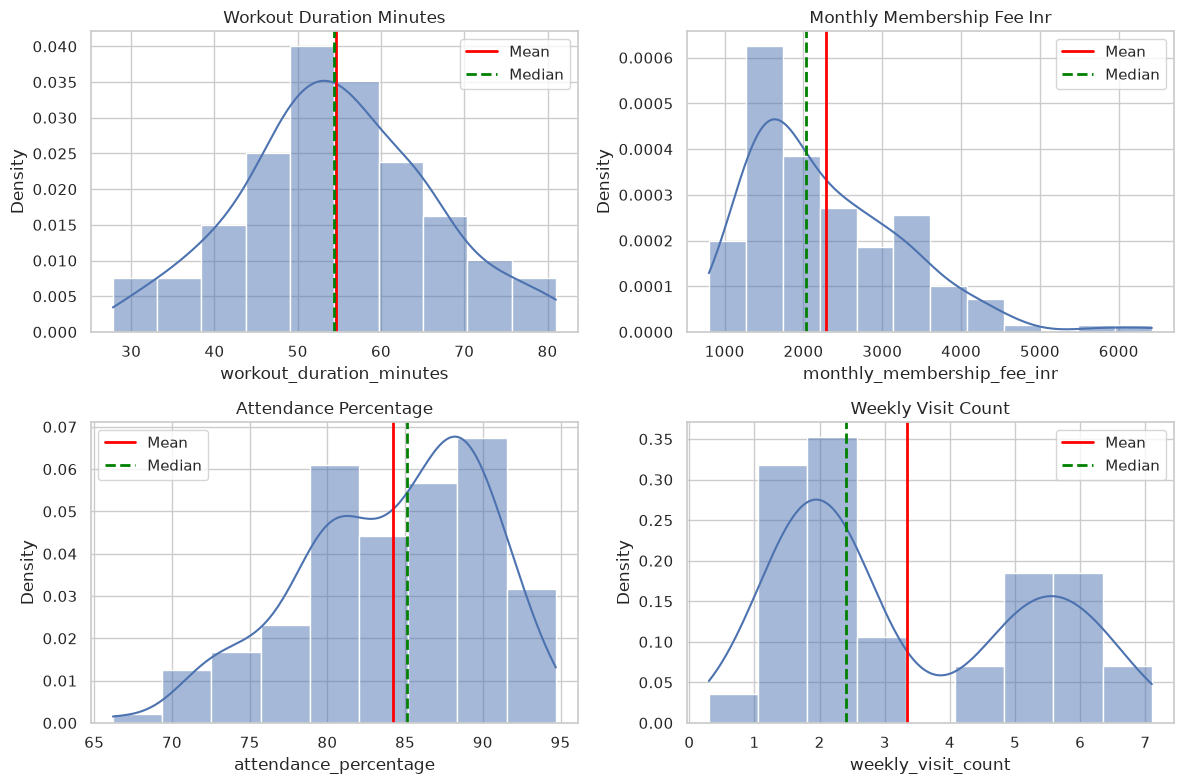

In [27]:
# TODO: Q9 — 2x2 histogram grid with KDE, mean line, and median line per feature

FEATURES = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, FEATURES):
    mean_val = df[col].mean()
    median_val = df[col].median()

    sns.histplot(df[col], kde=True, stat="density", bins="auto", ax=ax)

    # Mean line (solid red)
    ax.axvline(mean_val, color="red", linestyle="-", linewidth=2, label="Mean")

    # Median line (dashed green)
    ax.axvline(median_val, color="green", linestyle="--", linewidth=2, label="Median")

    ax.set_title(col.replace("_", " ").title())
    ax.legend()

plt.tight_layout()
plt.show()

### Q10 

Does the histogram for the feature you predicted in Q8 confirm or contradict your prediction?
If your prediction was wrong, which feature actually turned out to be bimodal, and does the mean
computed in Q2 fall in a sensible place on that histogram, or does it fall in an empty "valley"?

**Your answer: i was wrong the feature that turned out to be the bimodial was weekly visit count**

### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

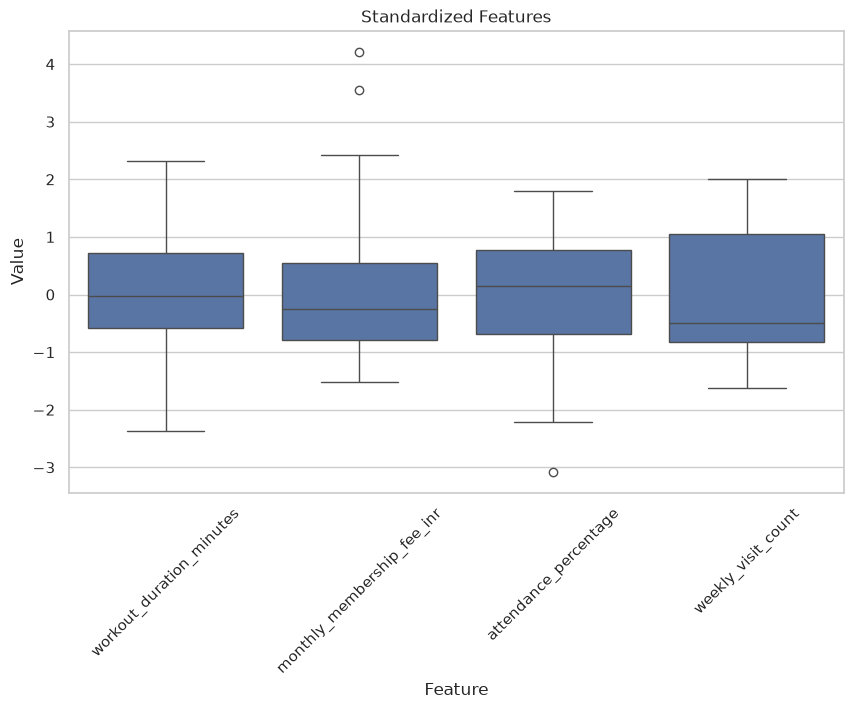

In [30]:
from sklearn.preprocessing import StandardScaler

# TODO: Q11 — standardize all four features and plot them as side-by-side box plots



scaler = StandardScaler()
df_standardized = df.copy()
df_standardized[FEATURES] = scaler.fit_transform(df[FEATURES])

# Reshape the standardized data for box plot
df_melted = df_standardized.melt(value_vars=FEATURES, var_name="Feature", value_name="Value")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_melted, x="Feature", y="Value")
plt.title("Standardized Features")
plt.xticks(rotation=45)
plt.show()

### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Your answer (1–2 sentences per pair):** Did the scatter plots and correlation values support your
hypotheses? If a result surprised you, say so.

**i was right about the attendance - visit count pair being little positively correlated to each other , and also the workout duration -membership fee are barely correlated**

In [31]:
# TODO: Q12 — two scatter plots (one hypothesized relationship, one hypothesized no relationship)

Correlation_1 = df["attendance_percentage"].corr(df["weekly_visit_count"])
print(Correlation_1)

0.5207696571703806


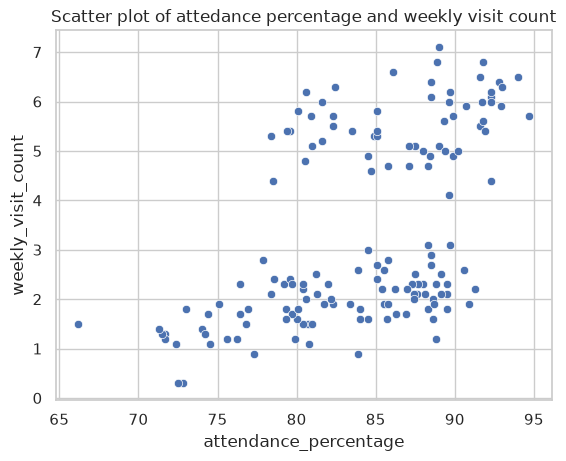

In [33]:
sns.scatterplot(data = df, x = "attendance_percentage" , y="weekly_visit_count")
plt.title("Scatter plot of attedance percentage and weekly visit count")
plt.show()

In [32]:
Correlation_2 = df["workout_duration_minutes"].corr(df["monthly_membership_fee_inr"])
print(Correlation_2)

-0.020847492609997808


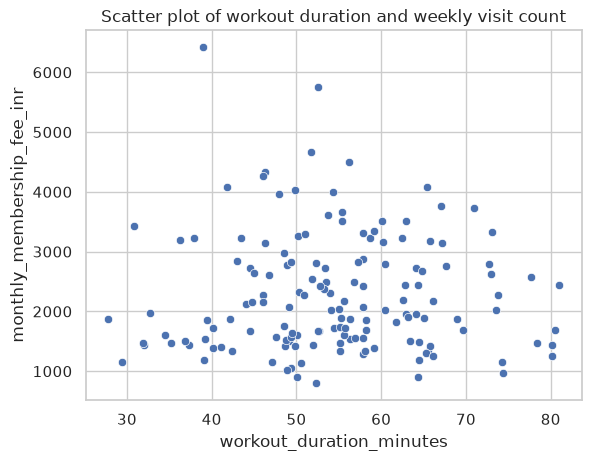

In [34]:
sns.scatterplot(data = df, x = "workout_duration_minutes" , y="monthly_membership_fee_inr")
plt.title("Scatter plot of workout duration and weekly visit count")
plt.show()

## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [35]:
# TODO: Q13 — assemble the comparative summary table

summary_table = pd.DataFrame({
    "Mean": df[FEATURES].mean(),
    "Median": df[FEATURES].median(),
    "Standard deviation": df[FEATURES].std(),
    "IQR": df[FEATURES].quantile(0.75) - df[FEATURES].quantile(0.25),
    "Skewness": df[FEATURES].skew(),
    "Excess kurtosis": df[FEATURES].kurtosis()
})

display(summary_table)

,Mean,Median,Standard deviation,IQR,Skewness,Excess kurtosis
workout_duration_minutes,54.618,54.35,11.397,14.825,0.081,-0.160
monthly_membership_fee_inr,2283.067,2030.00,984.837,1310.000,1.177,1.863
attendance_percentage,84.210,85.10,5.874,8.600,-0.561,-0.324
weekly_visit_count,3.337,2.40,1.886,3.500,0.446,-1.375


**Your answer (recommendation paragraph):**

For workout_duration_minutes, the mean is 54.618 and the median is 54.35—almost identical. Skewness here is just 0.081, so this distribution’s nearly symmetric. The standard deviation is 11.397 and the IQR is 14.825, which means it makes sense to report the mean along with the standard deviation.

For monthly_membership_fee_inr, things look different. The mean is 2283.067, a good deal higher than the median of 2030.000. Skewness is 1.177 with excess kurtosis at 1.863, so there’s a definite right skew and a heavy tail. In this case, you should use the median and IQR instead.

Looking at attendance_percentage, the mean is 84.210 and the median is 85.10—pretty close together—but the skewness is −0.561, so it leans left with a mild tail on that side. Here, too, it’s safer to go with the median and IQR.

Weekly_visit_count is right-skewed. The mean sits at 3.337 while the median’s at 2.40, and the skewness is 0.446, so again, the median and IQR are the best stats to report.


---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

In [36]:
# TODO (bonus): groupby preferred_workout, compare mean attendance_percentage across categories

attendance_by_workout = df.groupby("preferred_workout")["attendance_percentage"].mean()
print(attendance_by_workout)

preferred_workout
Cardio      83.558
CrossFit    82.325
Weights     85.526
Yoga        84.029
Name: attendance_percentage, dtype: float64


**Answer:-**
So the difference is pretty small—Weights lead with the highest mean attendance around 85.53%, while CrossFit sits at the bottom with about 82.33%. The categories aren’t all that far apart, so there’s no solid proof that any one workout type pulls in a lot more people.

---

### Before you submit
- [ ] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [ ] Every `# TODO` cell has working code, not just comments
- [ ] Every "Your answer" cell has a written response in your own words
- [ ] Did not modify the Part 1 dataset-generation code or the random seed